In [10]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


data_dir_rerun = Path(r"C:\Users\myles\OneDrive\Desktop\data_new")  # <-- update folder name
files_rerun = sorted(data_dir_rerun.glob(("run_phi*_mus*_mur*")))
print("Rerun files found:", len(files_rerun))

def find_table_start(path):
    with open(path, "r") as f:
        for i, line in enumerate(f):
            if line.strip().startswith("Time"):
                return i
    raise ValueError(f"No table header found in {path}")

# Find the end of the table by locating the line that begins with "Loop"
def find_table_end(path):
    with open(path, "r") as f:
        for i, line in enumerate(f):
            if line.strip().startswith("Loop"):
                return i
    return None  # If no end marker is found, return Non

Rerun files found: 29


In [11]:
columns_rerun = []
for file in files_rerun:
    start = find_table_start(file)
    end = find_table_end(file)
    df = pd.read_csv(file, delim_whitespace=True, skiprows=start,
                     nrows=end - start if end is not None else None,
                     on_bad_lines="skip", engine="python")
    col = df.iloc[:, 4].rename(f"{Path(file).stem}_stress_xy_rerun")
    columns_rerun.append(col)

df_rerun = pd.concat(columns_rerun, axis=1)
df_rerun.insert(0, "Time", range(len(df_rerun)))

eta_f = 0.1; gamma_dot = 0.01
for col in [c for c in df_rerun.columns if c != "Time"]:
    df_rerun[f"reduced_{col}"] = np.abs(df_rerun[col] / (eta_f * gamma_dot))

steady_rerun = df_rerun[(df_rerun["Time"] >= 200)]
reduced_cols_rerun = [c for c in df_rerun.columns if c.startswith("reduced_")]

avg_rerun = steady_rerun[reduced_cols_rerun].mean()
tau_strain = 1.0                          # 1 strain unit, as advised
dt_strain  = gamma_dot                    # each timestep = gamma_dot strain units (= 0.01)
tau_steps  = tau_strain / dt_strain       # = 100 timesteps per correlation time
N          = len(steady_rerun)
n_eff      = N / (2 * tau_steps + 1)     # effective independent samples
std_rerun  = steady_rerun[reduced_cols_rerun].std() / np.sqrt(n_eff)


fric_1_1_rerun = avg_rerun[avg_rerun.index.str.contains("mus1_mur1")]
sem_1_1_rerun  = std_rerun[std_rerun.index.str.contains("mus1_mur1")].values

fric_1_0_rerun = avg_rerun[avg_rerun.index.str.contains("mus1_mur0")]
sem_1_0_rerun  = std_rerun[std_rerun.index.str.contains("mus1_mur0")].values

fric_0_0_rerun = avg_rerun[avg_rerun.index.str.contains("mus0_mur0")]
sem_0_0_rerun  = std_rerun[std_rerun.index.str.contains("mus0_mur0")].values
# Set packing fractions to match your rerun phi values (update as needed)
x_1_1_rerun = [0.35, 0.36, 0.37, 0.38, 0.39, 0.40, 0.41, 0.42, 0.43, 0.44, 0.45]   # <-- fill in your rerun phi values
y_1_1_rerun = np.sort(fric_1_1_rerun.values)

x_1_0_rerun = [0.50, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57]   # <-- fill in your rerun phi values
y_1_0_rerun = np.sort(fric_1_0_rerun.values)

x_0_0_rerun = [0.55, 0.56, 0.57, 0.58, 0.59, 0.60, 0.61, 0.62, 0.63, 0.64]   # <-- fill in your rerun phi values
y_0_0_rerun = np.sort(fric_0_0_rerun.values)

C:\Users\myles\AppData\Local\Temp\ipykernel_94048\707232691.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file, delim_whitespace=True, skiprows=start,
C:\Users\myles\AppData\Local\Temp\ipykernel_94048\707232691.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file, delim_whitespace=True, skiprows=start,
C:\Users\myles\AppData\Local\Temp\ipykernel_94048\707232691.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file, delim_whitespace=True, skiprows=start,
C:\Users\myles\AppData\Local\Temp\ipykernel_94048\707232691.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Us

<>:45: SyntaxWarning: invalid escape sequence '\e'
<>:45: SyntaxWarning: invalid escape sequence '\e'
C:\Users\myles\AppData\Local\Temp\ipykernel_94048\2363069794.py:45: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('$\eta_r$', fontsize=18, fontweight='bold')
C:\Users\myles\AppData\Local\Temp\ipykernel_94048\2363069794.py:2: RuntimeWarning: divide by zero encountered in power
  return (1-x/xm)**(-2)


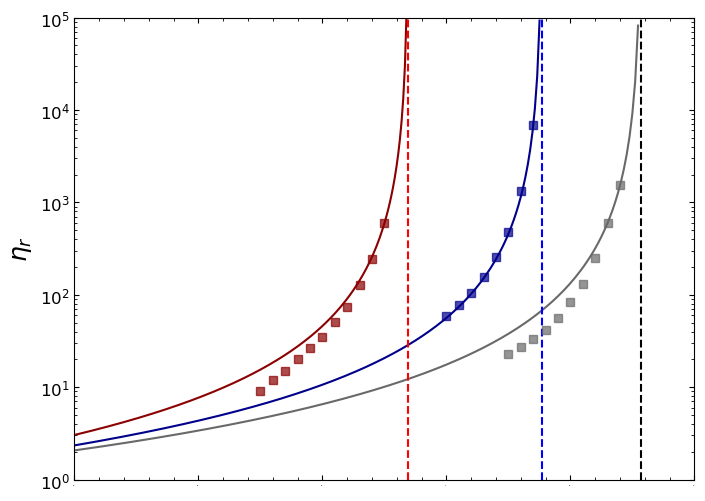

Fitted parameters for muS1, muR1 (xm, A, B): [0.46920924]
Fitted parameters for muS1, muR0 (xm, A, B): [0.57696707]
Fitted parameters for muS0, muR0 (xm, A, B): [0.6567834]


In [12]:
def func_fixed(x, xm):
    return (1-x/xm)**(-2)

params_1_1_rerun, _ = curve_fit(func_fixed, x_1_1_rerun, y_1_1_rerun, p0=[0.4505] , maxfev=10000000)
x_1_1_rerun_fit = np.linspace(0.20, params_1_1_rerun[0], 200)
y_1_1_rerun_fit = func_fixed(x_1_1_rerun_fit, *params_1_1_rerun)

params_1_0_rerun, _ = curve_fit(func_fixed, x_1_0_rerun, y_1_0_rerun, p0=[0.5702], maxfev=10000)
x_1_0_rerun_fit = np.linspace(0.20, params_1_0_rerun[0], 200)
y_1_0_rerun_fit = func_fixed(x_1_0_rerun_fit, *params_1_0_rerun)

params_0_0_rerun, _ = curve_fit(func_fixed, x_0_0_rerun, y_0_0_rerun, p0=[0.6477], maxfev=100000)
x_0_0_rerun_fit = np.linspace(0.20, params_0_0_rerun[0], 200)
y_0_0_rerun_fit = func_fixed(x_0_0_rerun_fit, *params_0_0_rerun)

# Plot the three curves together for comparison, (curves run from 0.20 to their xm value)
plt.figure(figsize=(8,6))

plt.errorbar(x_1_1_rerun, y_1_1_rerun, 
             label='muS1, muR1 (rerun)', marker='s', linestyle='none',
             color='darkred', alpha=0.7)

plt.errorbar(x_1_0_rerun, y_1_0_rerun, 
             label='muS1, muR0 (rerun)', marker='s', linestyle='none',
             color='darkblue', alpha=0.7)

plt.errorbar(x_0_0_rerun, y_0_0_rerun, 
             label='muS0, muR0 (rerun)', marker='s', linestyle='none',
             color='dimgray', alpha=0.7)

plt.plot(x_1_1_rerun_fit, y_1_1_rerun_fit, label=f'muS1, muR1 fit', color='darkred')

plt.plot(x_1_0_rerun_fit, y_1_0_rerun_fit, label=f'muS1, muR0 fit', color='darkblue')

plt.plot(x_0_0_rerun_fit, y_0_0_rerun_fit, label=f'muS0, muR0 fit', color='dimgray')

# Add jamming fraction lines
plt.axvline(x=params_1_1_rerun[0], color='red', linestyle='--', label='Fitted Jamming Fraction (muS1, muR1)')
plt.axvline(x=params_1_0_rerun[0], color='blue', linestyle='--', label='Fitted Jamming Fraction (muS1, muR0)')
plt.axvline(x=params_0_0_rerun[0], color='black', linestyle='--', label='Fitted Jamming Fraction (muS0, muR0)')

#plt.xlabel("$\phi$", fontsize=18, fontweight='bold')
plt.minorticks_on()
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)
plt.ylabel('$\eta_r$', fontsize=18, fontweight='bold')
plt.xticks(fontsize=0)
plt.yticks(fontsize=12)

plt.ylim(1, 1e5)
plt.yscale('log')
plt.xlim(0.20, 0.70)
plt.grid(False)
plt.show()

print("Fitted parameters for muS1, muR1 (xm, A, B):", params_1_1_rerun)
print("Fitted parameters for muS1, muR0 (xm, A, B):", params_1_0_rerun)
print("Fitted parameters for muS0, muR0 (xm, A, B):", params_0_0_rerun)

In [13]:
columns_rerun_z = []  # initialise immediately before the loop

for file in files_rerun:
    start = find_table_start(file)
    end = find_table_end(file)
    df = pd.read_csv(
        file,
        sep=r"\s+",
        skiprows=start,
        nrows=end - start if end is not None else None,
        on_bad_lines="skip",
        engine="python"
    )
    col_1 = df.iloc[:, 7].rename(f"{Path(file).stem}_stress_xy")
    columns_rerun_z.append(col_1)

print(f"Collected {len(columns_rerun_z)} columns")  # should match len(files_rerun)

contact_df = pd.concat(columns_rerun_z, axis=1)
contact_df.insert(0, "Time", range(len(contact_df)))
contact_df.head()



Collected 29 columns


,Time,run_phi0.35_mus1_mur1_stress_xy,run_phi0.36_mus1_mur1_stress_xy,run_phi0.37_mus1_mur1_stress_xy,run_phi0.38_mus1_mur1_stress_xy,run_phi0.39_mus1_mur1_stress_xy,run_phi0.40_mus1_mur1_stress_xy,run_phi0.41_mus1_mur1_stress_xy,run_phi0.42_mus1_mur1_stress_xy,run_phi0.43_mus1_mur1_stress_xy,...,run_phi0.56_mus1_mur0_stress_xy,run_phi0.57_mus0_mur0_stress_xy,run_phi0.57_mus1_mur0_stress_xy,run_phi0.58_mus0_mur0_stress_xy,run_phi0.59_mus0_mur0_stress_xy,run_phi0.60_mus0_mur0_stress_xy,run_phi0.61_mus0_mur0_stress_xy,run_phi0.62_mus0_mur0_stress_xy,run_phi0.63_mus0_mur0_stress_xy,run_phi0.64_mus0_mur0_stress_xy
0,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.002,0.000,0.000,0.000,0.000,0.000,0.000
1,1,0.004,0.004,0.002,0.006,0.006,0.004,0.002,0.004,0.008,...,0.020,0.008,0.008,0.026,0.032,0.052,0.076,0.092,0.210,0.754
2,2,0.004,0.006,0.002,0.006,0.010,0.004,0.004,0.006,0.014,...,0.030,0.018,0.018,0.040,0.068,0.084,0.184,0.192,0.540,1.860
3,3,0.006,0.004,0.006,0.004,0.014,0.004,0.010,0.010,0.016,...,0.040,0.030,0.030,0.054,0.088,0.142,0.314,0.370,1.084,3.108
4,4,0.006,0.006,0.006,0.006,0.016,0.004,0.010,0.012,0.018,...,0.046,0.048,0.046,0.086,0.126,0.260,0.524,0.798,1.876,4.086


In [14]:



steady_contact_df = contact_df[(contact_df["Time"] >= 200)]
reduced_cols = [col for col in steady_contact_df.columns if col != "Time"]
print("Reduced columns:", reduced_cols)

avg_contact = steady_contact_df[reduced_cols].mean()
print("Average Coordinate Number in Steady State:")
print(avg_contact)

fric_1_1_rerun_z = avg_contact[avg_contact.index.str.contains("mus1_mur1")]

fric_1_0_rerun_z = avg_contact[avg_contact.index.str.contains("mus1_mur0")]


fric_0_0_rerun_z = avg_contact[avg_contact.index.str.contains("mus0_mur0")]


y_1_1_rerun_z = np.sort(fric_1_1_rerun_z.values)
y_1_0_rerun_z = np.sort(fric_1_0_rerun_z.values)
y_0_0_rerun_z = np.sort(fric_0_0_rerun_z.values)



Reduced columns: ['run_phi0.35_mus1_mur1_stress_xy', 'run_phi0.36_mus1_mur1_stress_xy', 'run_phi0.37_mus1_mur1_stress_xy', 'run_phi0.38_mus1_mur1_stress_xy', 'run_phi0.39_mus1_mur1_stress_xy', 'run_phi0.40_mus1_mur1_stress_xy', 'run_phi0.41_mus1_mur1_stress_xy', 'run_phi0.42_mus1_mur1_stress_xy', 'run_phi0.43_mus1_mur1_stress_xy', 'run_phi0.44_mus1_mur1_stress_xy', 'run_phi0.45_mus1_mur1_stress_xy', 'run_phi0.50_mus1_mur0_stress_xy', 'run_phi0.51_mus1_mur0_stress_xy', 'run_phi0.52_mus1_mur0_stress_xy', 'run_phi0.53_mus1_mur0_stress_xy', 'run_phi0.54_mus1_mur0_stress_xy', 'run_phi0.55_mus0_mur0_stress_xy', 'run_phi0.55_mus1_mur0_stress_xy', 'run_phi0.56_mus0_mur0_stress_xy', 'run_phi0.56_mus1_mur0_stress_xy', 'run_phi0.57_mus0_mur0_stress_xy', 'run_phi0.57_mus1_mur0_stress_xy', 'run_phi0.58_mus0_mur0_stress_xy', 'run_phi0.59_mus0_mur0_stress_xy', 'run_phi0.60_mus0_mur0_stress_xy', 'run_phi0.61_mus0_mur0_stress_xy', 'run_phi0.62_mus0_mur0_stress_xy', 'run_phi0.63_mus0_mur0_stress_xy', 'r

<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
C:\Users\myles\AppData\Local\Temp\ipykernel_94048\1597847850.py:26: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("$\phi$", fontsize=18, fontweight='bold')


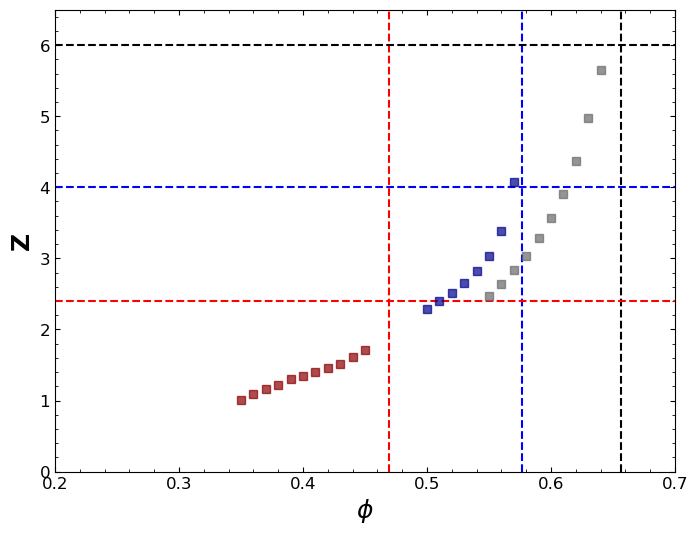

Fitted parameters for muS1, muR1 (xm, A, B): [0.46920924]
Fitted parameters for muS1, muR0 (xm, A, B): [0.57696707]
Fitted parameters for muS0, muR0 (xm, A, B): [0.6567834]


In [15]:
# Plot the three curves together for comparison, (curves run from 0.20 to their xm value)
plt.figure(figsize=(8,6))

plt.errorbar(x_1_1_rerun, y_1_1_rerun_z, 
             label='muS1, muR1 (rerun)', marker='s', linestyle='none',
             color='darkred', alpha=0.7)

plt.errorbar(x_1_0_rerun, y_1_0_rerun_z, 
             label='muS1, muR0 (rerun)', marker='s', linestyle='none',
             color='darkblue', alpha=0.7)

plt.errorbar(x_0_0_rerun, y_0_0_rerun_z, 
             label='muS0, muR0 (rerun)', marker='s', linestyle='none',
             color='dimgray', alpha=0.7)


# Add jamming fraction lines
plt.axvline(x=params_1_1_rerun[0], color='red', linestyle='--', label='Fitted Jamming Fraction (muS1, muR1)')
plt.axvline(x=params_1_0_rerun[0], color='blue', linestyle='--', label='Fitted Jamming Fraction (muS1, muR0)')
plt.axvline(x=params_0_0_rerun[0], color='black', linestyle='--', label='Fitted Jamming Fraction (muS0, muR0)')

plt.axhline(y=4,   color='b',     linestyle='--', label='Isostatic Coordinate Number = 4')
plt.axhline(y=2.4, color='r',     linestyle='--', label='Fitted Jamming Coordinate Number = 2.4')
plt.axhline(y=6,   color='black', linestyle='--', label='Maximum Coordinate Number = 6')

plt.xlabel("$\phi$", fontsize=18, fontweight='bold')
plt.minorticks_on()
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)
plt.ylabel('Z', fontsize=18, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.xlim(0.20, 0.7)
plt.ylim(0,6.5)
plt.grid(False)
plt.show()

print("Fitted parameters for muS1, muR1 (xm, A, B):", params_1_1_rerun)
print("Fitted parameters for muS1, muR0 (xm, A, B):", params_1_0_rerun)
print("Fitted parameters for muS0, muR0 (xm, A, B):", params_0_0_rerun)


C:\Users\myles\AppData\Local\Temp\ipykernel_94048\2568138588.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


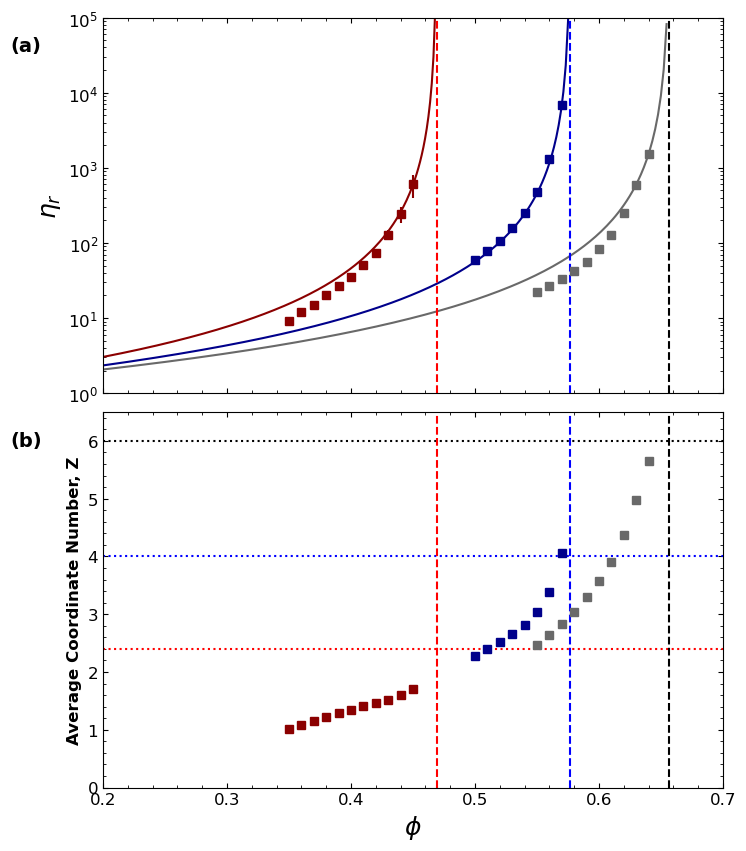

In [16]:
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1,
    figsize=(8, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1], "hspace": 0.05}
)

# === TOP: relative viscosity ===
ax_top.errorbar(x_1_1_rerun, y_1_1_rerun, yerr=sem_1_1_rerun,
                label='muS1, muR1', marker='s', linestyle='none',
                color='darkred', alpha=1)
ax_top.errorbar(x_1_0_rerun, y_1_0_rerun, yerr=sem_1_0_rerun,
                label='muS1, muR0', marker='s', linestyle='none',
                color='darkblue', alpha=1)
ax_top.errorbar(x_0_0_rerun, y_0_0_rerun, yerr=sem_0_0_rerun,
                label='muS0, muR0', marker='s', linestyle='none',
                color='dimgray', alpha=1)
ax_top.plot(x_1_1_rerun_fit, y_1_1_rerun_fit, color='darkred')
ax_top.plot(x_1_0_rerun_fit, y_1_0_rerun_fit, color='darkblue')
ax_top.plot(x_0_0_rerun_fit, y_0_0_rerun_fit, color='dimgray')
ax_top.set_ylabel(r'$\eta_r$', fontsize=18, fontweight='bold')
ax_top.set_yscale('log')
ax_top.set_ylim(1, 1e5)
ax_top.set_xlim(0.20, 0.70)
ax_top.minorticks_on()
ax_top.tick_params(axis='both', which='both', direction='in',
                   top=True, right=True, labelsize=12)
ax_top.grid(False)

# === BOTTOM: coordination number ===
ax_bot.errorbar(x_1_1_rerun, y_1_1_rerun_z,
                label='muS1, muR1', marker='s', linestyle='none',
                color='darkred', alpha=1)
ax_bot.errorbar(x_1_0_rerun, y_1_0_rerun_z,
                label='muS1, muR0', marker='s', linestyle='none',
                color='darkblue', alpha=1)
ax_bot.errorbar(x_0_0_rerun, y_0_0_rerun_z,
                label='muS0, muR0', marker='s', linestyle='none',
                color='dimgray', alpha=1)
ax_bot.axhline(y=4,   color='b',     linestyle=':', label='Isostatic Z = 4')
ax_bot.axhline(y=2.4, color='r',     linestyle=':', label='Jamming Z = 2.4')
ax_bot.axhline(y=6,   color='black', linestyle=':', label='Max Z = 6')
ax_bot.set_xlabel(r'$\phi$', fontsize=18, fontweight='bold')
ax_bot.set_ylabel('Average Coordinate Number, Z', fontsize=12, fontweight='bold')
ax_bot.set_ylim(0, 6.5)
ax_bot.minorticks_on()
ax_bot.tick_params(axis='both', which='both', direction='in',
                   top=True, right=True, labelsize=12)
ax_bot.grid(False)

# === Vertical jamming lines across both panels ===
jam_lines = [
    (params_1_1_rerun[0], 'red',   r'Jamming $\phi$ (muS1, muR1)'),
    (params_1_0_rerun[0], 'blue',  r'Jamming $\phi$ (muS1, muR0)'),   # fixed
    (params_0_0_rerun[0], 'black', r'Jamming $\phi$ (muS0, muR0)')
]
for xj, c, lab in jam_lines:
    ax_top.axvline(x=xj, color=c, linestyle='--', linewidth=1.5, label=lab)
    ax_bot.axvline(x=xj, color=c, linestyle='--', linewidth=1.5)

ax_top.text(-0.15, 0.95, '(a)', transform=ax_top.transAxes,
            fontsize=14, fontweight='bold', va='top')
ax_bot.text(-0.15, 0.95, '(b)', transform=ax_bot.transAxes,
            fontsize=14, fontweight='bold', va='top')

"""ax_top.legend(fontsize=9)
ax_bot.legend(fontsize=9)"""
plt.tight_layout()
plt.show()

In [17]:
import numpy as np
import pandas as pd
from scipy import signal
import matplotlib.pyplot as plt

# [Your existing code to load and filter data...]
steady_df = df_rerun[(df_rerun["Time"] >= 200) & (df_rerun["Time"] <= 3000)]
reduced_cols = [col for col in df_rerun.columns if col.startswith("reduced_")]

avg_reduced_stress = steady_df[reduced_cols].mean()
std_reduced_stress = steady_df[reduced_cols].std()

# ============================================================================
# NEW: CORRECTED UNCERTAINTY USING ACF
# ============================================================================

def autocorrelation_function(data, max_lag=None):
    """Calculate ACF efficiently using FFT."""
    data = np.asarray(data)
    data = data - np.mean(data)
    
    if max_lag is None:
        max_lag = len(data) // 3  # Use up to 1/3 of data length
    
    c0 = np.dot(data, data) / len(data)
    f = np.fft.fft(data, n=2*len(data))
    acf = np.fft.ifft(f * np.conjugate(f)).real / c0 / len(data)
    
    return acf[:max_lag+1]


def find_tau_corr(acf, threshold=1/np.e):
    """Find decorrelation timescale."""
    # Method: Find where ACF drops below threshold (1/e ≈ 0.368)
    threshold_lags = np.where(acf < threshold)[0]
    
    if len(threshold_lags) > 0:
        tau_corr = threshold_lags[0]
    else:
        # Fallback: use first zero crossing
        zero_cross = np.where(np.diff(np.sign(acf)))[0]
        if len(zero_cross) > 0:
            tau_corr = zero_cross[0]
        else:
            tau_corr = len(acf) - 1
    
    return tau_corr


def correct_sem_for_autocorr(data_series):
    """
    Calculate SEM corrected for temporal autocorrelation.
    
    Returns:
        sem_naive, sem_corrected, tau_corr, n_eff
    """
    n_total = len(data_series)
    std = data_series.std()
    
    # Naive SEM (assumes independence—WRONG)
    sem_naive = std / np.sqrt(n_total)
    
    # Calculate ACF
    acf = autocorrelation_function(data_series)
    tau_corr = find_tau_corr(acf)
    
    # Effective sample size
    n_eff = n_total / (2 * tau_corr + 1)
    
    # Corrected SEM
    sem_corrected = std / np.sqrt(n_eff)
    
    return sem_naive, sem_corrected, tau_corr, n_eff, acf


# ============================================================================
# APPLY TO EACH FRICTION REGIME
# ============================================================================

friction_combos = {
    "1_1": "muS1_muR1",
    "1_0": "muS1_muR0",
    "0_0": "muS0_muR0"
}

results_corrected = {}

for label, pattern in friction_combos.items():
    print(f"\n{'='*70}")
    print(f"FRICTION REGIME: {label}")
    print(f"{'='*70}")
    
    # Extract data for this friction combo
    cols_for_combo = [col for col in reduced_cols if pattern in col]
    data_for_combo = steady_df[cols_for_combo]
    
    print(f"Number of conditions (packing fractions): {len(cols_for_combo)}")
    print(f"Time points per condition: {len(data_for_combo)}")
    
    results_corrected[label] = {}
    
    # Process each packing fraction
    for col in cols_for_combo:
        data_series = data_for_combo[col].dropna()  # Remove any NaNs
        
        # Calculate means and uncertainty
        mean_visc = data_series.mean()
        sem_naive, sem_corrected, tau_corr, n_eff, acf = correct_sem_for_autocorr(data_series)
        
        # 95% confidence interval
        ci_95 = 1.96 * sem_corrected
        
        # Store results
        results_corrected[label][col] = {
            'mean': mean_visc,
            'std': data_series.std(),
            'sem_naive': sem_naive,
            'sem_corrected': sem_corrected,
            'tau_corr': tau_corr,
            'n_eff': n_eff,
            'ci_95': ci_95,
            'n_total': len(data_series),
            'acf': acf
        }
        
        # Print for one example (e.g., ϕ ≈ 0.50)
        if 'reduced_' in col and '0.50' in col:  # Adjust pattern to match your column names
            print(f"\nExample: {col}")
            print(f"  Mean viscosity:           {mean_visc:.4f}")
            print(f"  Std dev:                  {data_series.std():.4f}")
            print(f"  τ_corr:                   {tau_corr} time steps")
            print(f"  N_eff:                    {n_eff:.1f} (out of {len(data_series)})")
            print(f"  SEM (naive):              {sem_naive:.6f}")
            print(f"  SEM (corrected):          {sem_corrected:.6f}")
            print(f"  Correction factor:        {sem_corrected/sem_naive:.1f}×")
            print(f"  95% CI:                   ±{ci_95:.6f}")

# ============================================================================
# CREATE SUMMARY TABLE
# ============================================================================

print(f"\n{'='*70}")
print("SUMMARY TABLE (All Packing Fractions)")
print(f"{'='*70}\n")

for label in friction_combos.keys():
    print(f"\nFriction {label}:")
    print(f"{'ϕ':<8} {'Mean':<12} {'±95% CI':<12} {'τ_corr':<10} {'N_eff':<8}")
    print("-" * 60)
    
    for col, res in results_corrected[label].items():
        # Extract packing fraction from column name (adjust as needed)
        # Example: if col = "reduced_muS1_muR1_phi0.50", extract 0.50
        phi_str = col.split('phi')[-1] if 'phi' in col else '?'
        
        print(f"{phi_str:<8} {res['mean']:<12.4f} {res['ci_95']:<12.6f} "
              f"{res['tau_corr']:<10.0f} {res['n_eff']:<8.1f}")

# ============================================================================
# DIAGNOSTIC PLOTS (for one example condition)
# ============================================================================

# Pick one friction regime and one packing fraction to visualize
example_label = "1_1"
example_col = [col for col in results_corrected[example_label].keys()][0]
example_data = steady_df[example_col].dropna()
example_results = results_corrected[example_label][example_col]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: Time series with uncertainty band
ax = axes[0]
ax.plot(example_data.values, alpha=0.6, linewidth=0.8, label='Data')
ax.axhline(example_results['mean'], color='r', linestyle='--', linewidth=2, label='Mean')
ax.fill_between(range(len(example_data)), 
                 example_results['mean'] - example_results['ci_95'],
                 example_results['mean'] + example_results['ci_95'],
                 alpha=0.2, color='r', label='95% CI (corrected)')
ax.set_xlabel('Time step')
ax.set_ylabel('Reduced viscosity')
ax.set_title(f'Stress Time Series: {example_col}')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Autocorrelation function
ax = axes[1]
acf = example_results['acf']
lags = np.arange(len(acf))
ax.plot(lags, acf, 'o-', alpha=0.7, markersize=3)
ax.axhline(0, color='k', linestyle='-', linewidth=0.5)
ax.axhline(1/np.e, color='r', linestyle='--', alpha=0.7, label=f'1/e threshold')
ax.axvline(example_results['tau_corr'], color='r', linestyle=':', alpha=0.7,
           label=f"τ_corr = {example_results['tau_corr']:.0f}")
ax.set_xlabel('Lag (time steps)')
ax.set_ylabel('Autocorrelation')
ax.set_title('Autocorrelation Function')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, min(200, len(acf)))

plt.tight_layout()
plt.savefig('autocorr_analysis.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved diagnostic plots to: autocorr_analysis.png")
plt.show()


FRICTION REGIME: 1_1
Number of conditions (packing fractions): 0
Time points per condition: 2051

FRICTION REGIME: 1_0
Number of conditions (packing fractions): 0
Time points per condition: 2051

FRICTION REGIME: 0_0
Number of conditions (packing fractions): 0
Time points per condition: 2051

SUMMARY TABLE (All Packing Fractions)


Friction 1_1:
ϕ        Mean         ±95% CI      τ_corr     N_eff   
------------------------------------------------------------

Friction 1_0:
ϕ        Mean         ±95% CI      τ_corr     N_eff   
------------------------------------------------------------

Friction 0_0:
ϕ        Mean         ±95% CI      τ_corr     N_eff   
------------------------------------------------------------


IndexError: list index out of range